02-2-1 개념 설명용 
# LangGraph Human-in-the-Loop

## 실습 주제

> **Agent가 중요한 작업을 바로 실행하지 않고, 사람의 판단을 받은 뒤 작업을 이어가는 과정을 구현한다.**

이 노트북은 외부 LLM과 API Key를 사용하지 않는다.  
따라서 Human-in-the-Loop의 핵심 구조인 다음 흐름에 집중할 수 있다.

```text
Agent 실행
   ↓
사람의 판단이 필요한 지점
   ↓
interrupt()로 실행 중단
   ↓
Checkpoint에 상태 저장
   ↓
사람의 승인·수정·반려
   ↓
Command(resume=...)로 실행 재개
```


## 학습목표

실습을 마치면 다음 내용을 설명하고 구현할 수 있다.

1. Human-in-the-Loop가 필요한 이유를 설명할 수 있다.
2. `interrupt()`로 Graph 실행을 중단할 수 있다.
3. Checkpointer와 `thread_id`의 역할을 설명할 수 있다.
4. `Command(resume=...)`로 사람의 응답을 전달할 수 있다.
5. 승인, 수정, 반려 결과에 따라 실행 경로를 변경할 수 있다.


## 0. 먼저 상황을 생각해 보기

Agent가 고객 500명에게 보낼 이메일 초안을 작성했다고 가정한다.

```text
Agent가 이메일 초안 작성
        ↓
바로 500명에게 발송?
```

다음 문제가 있을 수 있다.

- 수신자가 잘못 지정될 수 있다.
- 제목이나 본문에 오류가 있을 수 있다.
- 개인정보가 포함될 수 있다.
- 발송 후에는 되돌리기 어렵다.

따라서 실제 업무에서는 다음 구조가 필요하다.

```text
Agent가 초안 작성
        ↓
사람이 검토
        ↓
승인·수정·반려
        ↓
승인된 경우에만 실행
```

이 구조가 Human-in-the-Loop의 대표적인 형태이다.


## 1. 실습 환경 준비

아래 셀은 LangGraph를 설치한다. 이미 설치되어 있다면 빠르게 완료된다.

> 설치 후 커널 재시작 안내가 표시되면 커널을 재시작하고 다음 셀부터 실행한다.


## 2. 필요한 모듈 불러오기

- `StateGraph`: 상태를 중심으로 Workflow를 구성한다.
- `START`, `END`: Graph의 시작점과 종료점이다.
- `InMemorySaver`: 실습용 Checkpointer이다.
- `interrupt`: 실행을 중단하고 사람의 입력을 요청한다.
- `Command`: 중단된 실행을 재개한다.


In [100]:
from typing import Literal, TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

print("LangGraph 모듈을 정상적으로 불러왔습니다.")

LangGraph 모듈을 정상적으로 불러왔습니다.


# 실습 1. 이메일 발송 승인 Workflow

## 3. 공유 State 정의

State는 Graph가 처리 중인 업무 정보를 보관하는 공유 객체이다.

이번 실습에서는 다음 정보를 저장한다.

| 필드 | 의미 |
|---|---|
| `recipients` | 이메일 수신자 |
| `subject` | 이메일 제목 |
| `body` | 이메일 본문 |
| `review_decision` | 승인·수정·반려 결과 |
| `reviewer_comment` | 검토자 의견 |
| `status` | 현재 업무 상태 |
| `audit_log` | 처리 이력 |


In [101]:
class EmailState(TypedDict, total=False):
    recipients: list[str]
    subject: str
    body: str
    review_decision: str
    reviewer_comment: str
    status: str
    audit_log: list[str]

## 4. Node 함수 작성

### 4-1. 이메일 초안 준비 Node

이 Node는 실제 LLM 대신 미리 입력된 이메일을 발송 준비 상태로 만든다.


In [102]:
def prepare_draft(state: EmailState) -> EmailState:
    log = state.get("audit_log", []) + [
        "Agent가 이메일 초안을 발송 준비 상태로 변경함"
    ]

    return {
        "status": "human_review_waiting",
        "audit_log": log,
    }

### 4-2. 사람의 검토를 요청하는 Node

`interrupt()`가 실행되면 Graph는 다음 작업을 수행한다.

1. 현재 실행을 중단한다.
2. State를 Checkpoint에 저장한다.
3. 검토 요청 정보를 호출자에게 전달한다.
4. 사람의 응답이 들어올 때까지 기다린다.

사람이 보낸 값은 실행 재개 시 `interrupt()`의 반환값이 된다.


In [103]:
def human_review(state: EmailState) -> EmailState:
    # interrupt 이전에는 이메일 발송과 같은 실제 부수 효과를 실행하지 않는다.
    review_payload = {
        "task": "email_review",
        "question": "이 이메일을 발송하시겠습니까?",
        "draft": {
            "recipients": state["recipients"],
            "subject": state["subject"],
            "body": state["body"],
        },
        "options": ["approve", "edit", "reject"],
    }

    # 여기서 Graph 실행이 중단된다.
    human_response = interrupt(review_payload)

    # 실행을 재개하면 Command(resume=...)에 전달한 값이 들어온다.
    if not isinstance(human_response, dict):
        human_response = {"decision": str(human_response)}

    decision = str(human_response.get("decision", "reject")).lower()
    comment = str(human_response.get("comment", ""))

    updates: EmailState = {
        "review_decision": decision,
        "reviewer_comment": comment,
        "audit_log": state.get("audit_log", []) + [
            f"사람의 검토 결과를 수신함: {decision}"
        ],
    }

    # edit를 선택하면 사람이 수정한 제목과 본문을 State에 반영한다.
    if decision == "edit":
        updates["subject"] = human_response.get("subject", state["subject"])
        updates["body"] = human_response.get("body", state["body"])

    return updates

### 4-3. 승인 결과에 따라 실행할 Node

실제 이메일은 발송하지 않는다.  
교육용으로 발송 상태만 변경한다.


In [104]:
def send_email(state: EmailState) -> EmailState:
    recipient_count = len(state["recipients"])

    return {
        "status": "sent_simulation",
        "audit_log": state.get("audit_log", []) + [
            f"이메일 발송을 시뮬레이션함: 수신자 {recipient_count}명"
        ],
    }


def reject_email(state: EmailState) -> EmailState:
    return {
        "status": "rejected",
        "audit_log": state.get("audit_log", []) + [
            "검토자가 이메일 발송을 반려함"
        ],
    }

### 4-4. 조건 분기 함수

- `approve`: 원본을 그대로 발송한다.
- `edit`: 사람이 수정한 내용을 발송한다.
- `reject`: 발송하지 않는다.


In [105]:
def route_after_review(state: EmailState) -> Literal["send", "reject"]:
    if state.get("review_decision") in {"approve", "edit"}:
        return "send"

    return "reject"


## 5. Graph 구성

Graph의 실행 흐름은 다음과 같다.

```text
START
  ↓
prepare_draft
  ↓
human_review
  ├─ approve 또는 edit → send_email → END
  └─ reject           → reject_email → END
```


In [106]:
builder = StateGraph(EmailState)

builder.add_node("prepare_draft", prepare_draft)
builder.add_node("human_review", human_review)
builder.add_node("send_email", send_email)
builder.add_node("reject_email", reject_email)

builder.add_edge(START, "prepare_draft")
builder.add_edge("prepare_draft", "human_review")

builder.add_conditional_edges(
    "human_review",
    route_after_review,
    {
        "send": "send_email",
        "reject": "reject_email",
    },
)

builder.add_edge("send_email", END)
builder.add_edge("reject_email", END)

# 실습용 메모리 Checkpointer
checkpointer = InMemorySaver()

email_graph = builder.compile(checkpointer=checkpointer)

print("Graph 구성이 완료되었습니다.")

Graph 구성이 완료되었습니다.


## 6. Graph 구조 확인

Mermaid 문법으로 Graph 구조를 출력한다.


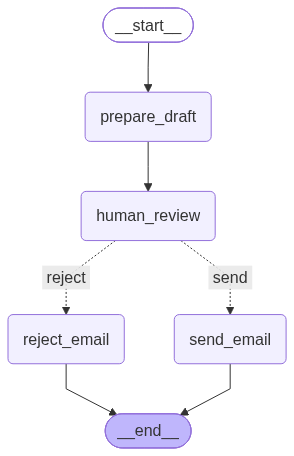

In [107]:
from agentic_ai.notebook_utils import show_graph
show_graph(email_graph)

## 7. 첫 번째 실행: 사람의 검토 지점에서 중단하기

`thread_id`는 중단된 작업을 다시 찾기 위한 업무 번호와 같다.

같은 작업을 재개하려면 반드시 같은 `thread_id`를 사용해야 한다.


In [108]:
initial_email: EmailState = {
    "recipients": [
        "customer01@example.com",
        "customer02@example.com",
        "customer03@example.com",
    ],
    "subject": "신규 교육과정 안내",
    "body": "안녕하세요. 신규 AI 교육과정을 안내드립니다.",
    "status": "draft",
    "audit_log": [],
}

config = {
    "configurable": {
        "thread_id": "email-case-001"
    }
}

paused_result = email_graph.invoke(initial_email, config=config)
paused_result

{'recipients': ['customer01@example.com',
  'customer02@example.com',
  'customer03@example.com'],
 'subject': '신규 교육과정 안내',
 'body': '안녕하세요. 신규 AI 교육과정을 안내드립니다.',
 'status': 'human_review_waiting',
 'audit_log': ['Agent가 이메일 초안을 발송 준비 상태로 변경함'],
 '__interrupt__': [Interrupt(value={'task': 'email_review', 'question': '이 이메일을 발송하시겠습니까?', 'draft': {'recipients': ['customer01@example.com', 'customer02@example.com', 'customer03@example.com'], 'subject': '신규 교육과정 안내', 'body': '안녕하세요. 신규 AI 교육과정을 안내드립니다.'}, 'options': ['approve', 'edit', 'reject']}, id='1eb2b747dbb5f1bf3f251c14826b004f')]}

## 8. Interrupt 요청 내용 확인

기본 invoke 방식에서는 중단 요청이 `__interrupt__`에 포함된다.


In [109]:
interrupts = paused_result.get("__interrupt__", [])

if interrupts:
    interrupt_item = interrupts[0]
    payload = getattr(interrupt_item, "value", interrupt_item)

    print("Graph가 사람의 입력을 기다리고 있습니다.")
    print("검토 요청 내용:")
    print(payload)
else:
    print("Interrupt가 발견되지 않았습니다.")

Graph가 사람의 입력을 기다리고 있습니다.
검토 요청 내용:
{'task': 'email_review', 'question': '이 이메일을 발송하시겠습니까?', 'draft': {'recipients': ['customer01@example.com', 'customer02@example.com', 'customer03@example.com'], 'subject': '신규 교육과정 안내', 'body': '안녕하세요. 신규 AI 교육과정을 안내드립니다.'}, 'options': ['approve', 'edit', 'reject']}


## 9. Checkpoint 상태 확인

Graph는 종료된 것이 아니다.  
`human_review` Node에서 중단된 상태로 저장되어 있다.


In [110]:
paused_snapshot = email_graph.get_state(config)

print("다음에 실행할 Node:", paused_snapshot.next)
print("저장된 State:")
paused_snapshot.values

다음에 실행할 Node: ('human_review',)
저장된 State:


{'recipients': ['customer01@example.com',
  'customer02@example.com',
  'customer03@example.com'],
 'subject': '신규 교육과정 안내',
 'body': '안녕하세요. 신규 AI 교육과정을 안내드립니다.',
 'status': 'human_review_waiting',
 'audit_log': ['Agent가 이메일 초안을 발송 준비 상태로 변경함']}

## 10. 사람의 응답 선택

아래 세 가지 예시 중 하나를 선택한다.  
처음에는 `approve_response`를 사용해 실행하는 것을 권장한다.


In [111]:
approve_response = {
    "decision": "approve",
    "comment": "내용과 수신자를 확인했습니다.",
}

edit_response = {
    "decision": "edit",
    "subject": "[수정] 신규 Agentic AI 교육과정 안내",
    "body": "안녕하세요. 검토를 완료한 신규 Agentic AI 교육과정을 안내드립니다.",
    "comment": "제목과 본문을 수정한 후 발송합니다.",
}

reject_response = {
    "decision": "reject",
    "comment": "수신자 목록을 다시 확인해야 합니다.",
}

# approve_response, edit_response, reject_response 중 하나를 지정한다.
human_response = approve_response

human_response

{'decision': 'approve', 'comment': '내용과 수신자를 확인했습니다.'}

## 11. 중단된 Graph 실행 재개

중요한 조건은 두 가지이다.

1. `Command(resume=사람의 응답)`을 사용한다.
2. 중단할 때 사용한 것과 동일한 `thread_id`를 사용한다.


In [112]:
final_result = email_graph.invoke(
    Command(resume=human_response),
    config=config,
)

final_result

{'recipients': ['customer01@example.com',
  'customer02@example.com',
  'customer03@example.com'],
 'subject': '신규 교육과정 안내',
 'body': '안녕하세요. 신규 AI 교육과정을 안내드립니다.',
 'review_decision': 'approve',
 'reviewer_comment': '내용과 수신자를 확인했습니다.',
 'status': 'sent_simulation',
 'audit_log': ['Agent가 이메일 초안을 발송 준비 상태로 변경함',
  '사람의 검토 결과를 수신함: approve',
  '이메일 발송을 시뮬레이션함: 수신자 3명']}

## 12. 최종 결과 확인


In [113]:
print("최종 상태:", final_result["status"])
print("검토 결과:", final_result["review_decision"])
print("검토 의견:", final_result.get("reviewer_comment", ""))

print("\n최종 이메일")
print("제목:", final_result["subject"])
print("본문:", final_result["body"])

print("\n처리 이력")
for index, log in enumerate(final_result["audit_log"], start=1):
    print(f"{index}. {log}")

최종 상태: sent_simulation
검토 결과: approve
검토 의견: 내용과 수신자를 확인했습니다.

최종 이메일
제목: 신규 교육과정 안내
본문: 안녕하세요. 신규 AI 교육과정을 안내드립니다.

처리 이력
1. Agent가 이메일 초안을 발송 준비 상태로 변경함
2. 사람의 검토 결과를 수신함: approve
3. 이메일 발송을 시뮬레이션함: 수신자 3명


## 13. 수정·반려 경로 실험

새로운 `thread_id`를 사용하면 별도의 업무가 시작된다.

아래 함수를 이용해 수정 또는 반려 경로를 빠르게 실험한다.


In [114]:
def run_email_case(
    thread_id: str,
    human_response: dict,
) -> EmailState:
    case_config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    # 1차 실행: interrupt에서 중단
    email_graph.invoke(initial_email, config=case_config)

    # 2차 실행: 사람의 응답으로 재개
    result = email_graph.invoke(
        Command(resume=human_response),
        config=case_config,
    )

    return result

In [115]:
edited_result = run_email_case(
    thread_id="email-case-edit",
    human_response=edit_response,
)

print("상태:", edited_result["status"])
print("수정된 제목:", edited_result["subject"])
print("수정된 본문:", edited_result["body"])

상태: sent_simulation
수정된 제목: [수정] 신규 Agentic AI 교육과정 안내
수정된 본문: 안녕하세요. 검토를 완료한 신규 Agentic AI 교육과정을 안내드립니다.


In [116]:
rejected_result = run_email_case(
    thread_id="email-case-reject",
    human_response=reject_response,
)

print("상태:", rejected_result["status"])
print("반려 의견:", rejected_result["reviewer_comment"])

상태: rejected
반려 의견: 수신자 목록을 다시 확인해야 합니다.


# 실습 2. 정보가 부족할 때 사람에게 질문하기

Human-in-the-Loop는 승인만을 위한 기능이 아니다.

Agent가 정확한 판단을 내리기 위해 필요한 정보가 부족한 경우에도 사용할 수 있다.

## 사례

사용자가 다음과 같이 입력했다.

> 생성형 AI를 활용하여 지원자의 자기소개서를 평가하려고 합니다.

하지만 다음 정보가 없다.

> AI 평가 결과가 실제 합격 여부를 결정하는 데 사용되는가?

Agent가 이를 임의로 추측하지 않고 사람에게 질문하도록 구현한다.


In [117]:
class ComplianceState(TypedDict, total=False):
    scenario: str
    human_answer: str
    assessment: str

In [118]:
def ask_missing_information(
    state: ComplianceState,
) -> ComplianceState:
    answer = interrupt({
        "task": "missing_information",
        "question": "AI 평가 결과가 실제 합격 여부를 직접 결정합니까?",
        "options": ["예", "아니오"],
        "scenario": state["scenario"],
    })

    return {
        "human_answer": str(answer)
    }


def assess_scenario(
    state: ComplianceState,
) -> ComplianceState:
    normalized = state["human_answer"].strip().lower()

    if normalized in {"예", "yes", "y", "true"}:
        assessment = (
            "AI 결과가 실제 선발 결정에 직접 사용되므로 "
            "위험성과 사람의 감독 절차를 우선 검토해야 합니다."
        )
    else:
        assessment = (
            "AI 결과는 참고자료로 사용되는 것으로 확인되었습니다. "
            "최종 결정 주체와 고지 절차를 추가 점검해야 합니다."
        )

    return {
        "assessment": assessment
    }

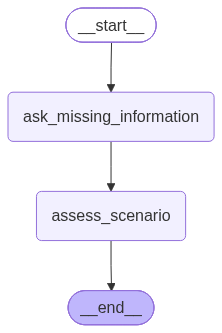

In [119]:
compliance_builder = StateGraph(ComplianceState)

compliance_builder.add_node(
    "ask_missing_information",
    ask_missing_information,
)
compliance_builder.add_node(
    "assess_scenario",
    assess_scenario,
)

compliance_builder.add_edge(START, "ask_missing_information")
compliance_builder.add_edge(
    "ask_missing_information",
    "assess_scenario",
)
compliance_builder.add_edge("assess_scenario", END)

compliance_graph = compliance_builder.compile(
    checkpointer=InMemorySaver()
)

show_graph(compliance_graph)

In [120]:
compliance_config = {
    "configurable": {
        "thread_id": "compliance-case-001"
    }
}

compliance_input: ComplianceState = {
    "scenario": "생성형 AI로 지원자의 자기소개서를 평가하려고 합니다."
}

compliance_paused = compliance_graph.invoke(
    compliance_input,
    config=compliance_config,
)

compliance_paused

{'scenario': '생성형 AI로 지원자의 자기소개서를 평가하려고 합니다.',
 '__interrupt__': [Interrupt(value={'task': 'missing_information', 'question': 'AI 평가 결과가 실제 합격 여부를 직접 결정합니까?', 'options': ['예', '아니오'], 'scenario': '생성형 AI로 지원자의 자기소개서를 평가하려고 합니다.'}, id='c8e0fea08e12c04cfb5d014b8a6fbb41')]}

In [121]:
compliance_interrupts = compliance_paused.get("__interrupt__", [])

if compliance_interrupts:
    item = compliance_interrupts[0]
    print(getattr(item, "value", item))

{'task': 'missing_information', 'question': 'AI 평가 결과가 실제 합격 여부를 직접 결정합니까?', 'options': ['예', '아니오'], 'scenario': '생성형 AI로 지원자의 자기소개서를 평가하려고 합니다.'}


### 사람의 답변을 반영하여 실행 재개

아래의 `"아니오"`를 `"예"`로 변경하여 결과 차이를 비교한다.


In [122]:
compliance_final = compliance_graph.invoke(
    Command(resume="아니오"),
    config=compliance_config,
)

print("사람의 답변:", compliance_final["human_answer"])
print("Agent의 후속 판단:", compliance_final["assessment"])

사람의 답변: 아니오
Agent의 후속 판단: AI 결과는 참고자료로 사용되는 것으로 확인되었습니다. 최종 결정 주체와 고지 절차를 추가 점검해야 합니다.


# 핵심 개념 정리

| 개념 | 실습에서 수행한 역할 |
|---|---|
| `State` | 이메일, 검토 결과, 처리 상태를 저장했다. |
| `interrupt()` | 사람의 검토나 추가 정보가 필요한 지점에서 실행을 중단했다. |
| Checkpointer | 중단된 Graph의 State와 실행 위치를 저장했다. |
| `thread_id` | 중단된 작업을 다시 찾는 업무 번호로 사용했다. |
| `Command(resume=...)` | 사람의 승인·수정·반려 또는 답변을 Graph에 전달했다. |
| Conditional Edge | 승인 결과에 따라 발송 또는 반려 경로를 선택했다. |

## HITL의 핵심 공식

```text
Human-in-the-Loop
=
실행 중단
+
상태 저장
+
사람의 입력
+
실행 재개
```


# 반드시 기억할 주의사항

## 1. Interrupt가 있는 Node는 재개 시 처음부터 다시 실행된다

`interrupt()`가 포함된 Node는 재개할 때 해당 Node의 처음부터 다시 실행된다.

따라서 `interrupt()` 이전에 다음과 같은 작업을 두면 안 된다.

- 실제 이메일 발송
- 결제 처리
- 데이터 삭제
- 중복 실행되면 문제가 발생하는 데이터베이스 변경

이러한 실제 행동은 사람의 승인이 완료된 다음 Node에 배치하는 것이 안전하다.

## 2. 같은 작업은 같은 `thread_id`로 재개한다

다른 `thread_id`를 사용하면 기존 작업을 이어가는 것이 아니라 새로운 작업으로 처리된다.

## 3. `InMemorySaver`는 실습용이다

커널을 종료하면 저장 내용이 사라진다.  
운영 환경에서는 SQLite, PostgreSQL 등 영속 저장소 기반 Checkpointer를 사용해야 한다.


# 도전 과제

다음 중 하나를 선택하여 Graph를 수정한다.

### 과제 1. 금액 기준 승인

- 10만 원 미만은 자동 승인한다.
- 10만 원 이상은 사람에게 승인을 요청한다.

### 과제 2. 개인정보 포함 여부 확인

- 이메일 본문에 개인정보가 있을 가능성이 있으면 사람에게 검토를 요청한다.
- 문제가 없으면 다음 단계로 이동한다.

### 과제 3. AI 기본법 사전점검 질문 확장

다음 정보를 순서대로 확인하도록 확장한다.

1. AI 결과가 최종 의사결정에 사용되는가?
2. 사람의 검토 절차가 있는가?
3. 사용자에게 AI 활용 사실을 고지하는가?

## 확인 질문

1. `interrupt()`가 없다면 어떤 문제가 발생할 수 있는가?
2. Checkpointer가 필요한 이유는 무엇인가?
3. 재개할 때 같은 `thread_id`가 필요한 이유는 무엇인가?
4. 이메일 발송 Node를 `interrupt()` 이전에 실행하면 왜 위험한가?


# 마무리

Human-in-the-Loop는 사람이 Agent의 모든 작업을 대신하는 구조가 아니다.

```text
자동화하기 안전한 작업
        → Agent가 자동 처리

불확실성·위험·책임이 큰 작업
        → 사람이 확인

사람의 판단이 완료된 작업
        → Agent가 이어서 처리
```

따라서 HITL은 자동화를 방해하는 기능이 아니라,  
**AI Agent를 실제 업무에 안전하고 책임 있게 적용하기 위한 실행 통제 구조**이다.
